In [35]:
import torch
import numpy as np

# —— 1) Load tensor —— 
data = torch.load('output3.pt').cpu()
arr  = data.numpy()

print(arr.shape)

print("Loaded array shape:", arr.shape)
# e.g. you might see (2, 128, 49, 20) or (128, 2, 49, 20), etc.

# —— 2) Find which axis holds the GT vs. prediction pair —— 
if arr.shape[0] == 2:
    # arr: (2, n_series, T, E)
    true_graphs = arr[0]   # → (n_series, T, E)
    pred_graphs = arr[1]
    n_series    = arr.shape[1]
elif arr.shape[1] == 2:
    # arr: (n_series, 2, T, E)
    true_graphs = arr[:, 0]
    pred_graphs = arr[:, 1]
    n_series    = arr.shape[0]
else:
    raise ValueError(
        f"Unexpected shape {arr.shape}: one axis must be size 2 (GT vs pred)."
    )

print(n_series)

print("True graphs shape:",  true_graphs.shape)
print("Pred graphs shape:",  pred_graphs.shape)
# e.g. True graphs shape: (128, 49, 20)

# —— 3) Sanity-check raw CP counts on first 5 series —— 
def raw_cps(graph_seq):
    """
    Return np.array of t indices where graph_seq[t] != graph_seq[t+1]
    in ANY edge.
    """
    diffs = np.any(graph_seq[:-1] != graph_seq[1:], axis=1)
    return np.where(diffs)[0]

print("\n--- First 5 series raw CP counts ---")
for i in range(min(5, n_series)):
    t_cps = raw_cps(true_graphs[i])
    p_cps = raw_cps(pred_graphs[i])
    print(f"Series {i}: True CPs={len(t_cps)} at {t_cps.tolist()}")
    print(f"          Pred CPs={len(p_cps)} at {p_cps.tolist()}")

# —— 4) Match with tolerance Δ and collect delays —— 
Δ = 49  # tolerance window ±Δ time‐steps

def match_with_tolerance(true_cps, pred_cps, Δ):
    """
    Greedily match each true CP to the nearest unmatched pred CP
    within ±Δ. Returns (delays, TP, FP, FN).
    """
    delays = []
    matched_pred = set()
    matched_true = set()
    
    for t in true_cps:
        cands = [p for p in pred_cps 
                 if abs(p - t) <= Δ and p not in matched_pred]
        if not cands:
            continue
        p_best = min(cands, key=lambda p: abs(p - t))
        matched_true.add(t)
        matched_pred.add(p_best)
        delays.append(p_best - t)
    
    TP = len(matched_true)
    FP = len(pred_cps) - TP
    FN = len(true_cps) - TP
    return delays, TP, FP, FN

# —— 5) Aggregate over all series —— 
all_delays = []
TP = FP = FN = 0

for i in range(n_series):
    t_cps = raw_cps(true_graphs[i])
    p_cps = raw_cps(pred_graphs[i])
    delays, tp, fp, fn = match_with_tolerance(t_cps, p_cps, Δ)
    
    all_delays.extend(delays)
    TP += tp
    FP += fp
    FN += fn

# —— 6) Compute Precision / Recall / F1 —— 
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1_score  = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else 0.0)

# —— 7) Summarize delays —— 
mean_delay   = np.mean(all_delays)   if all_delays else np.nan
median_delay = np.median(all_delays) if all_delays else np.nan
std_delay    = np.std(all_delays)    if all_delays else np.nan

# —— 8) Print final results —— 
print(f"\n=== Evaluation (Δ = {Δ}) ===")
print(f"True Positives : {TP}")
print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")
print(f"Precision      : {precision:.3f}")
print(f"Recall         : {recall:.3f}")
print(f"F1 Score       : {f1_score:.3f}")

print("\nDetection Delays (predicted − true):")
print(f"  Mean   = {mean_delay:.3f} steps")
print(f"  Median = {median_delay:.3f} steps")
print(f"  StdDev = {std_delay:.3f} steps")


/tmp/ipykernel_40545/559021478.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load('output3.pt').cpu()


(10000, 2, 49, 20)
Loaded array shape: (10000, 2, 49, 20)
10000
True graphs shape: (10000, 49, 20)
Pred graphs shape: (10000, 49, 20)

--- First 5 series raw CP counts ---
Series 0: True CPs=0 at []
          Pred CPs=0 at []
Series 1: True CPs=1 at [44]
          Pred CPs=0 at []
Series 2: True CPs=3 at [19, 37, 43]
          Pred CPs=2 at [18, 19]
Series 3: True CPs=3 at [3, 18, 33]
          Pred CPs=5 at [7, 18, 33, 34, 36]
Series 4: True CPs=1 at [11]
          Pred CPs=4 at [10, 16, 27, 32]

=== Evaluation (Δ = 49) ===
True Positives : 12690
False Positives: 7348
False Negatives: 2143
Precision      : 0.633
Recall         : 0.856
F1 Score       : 0.728

Detection Delays (predicted − true):
  Mean   = 1.284 steps
  Median = 1.000 steps
  StdDev = 7.230 steps


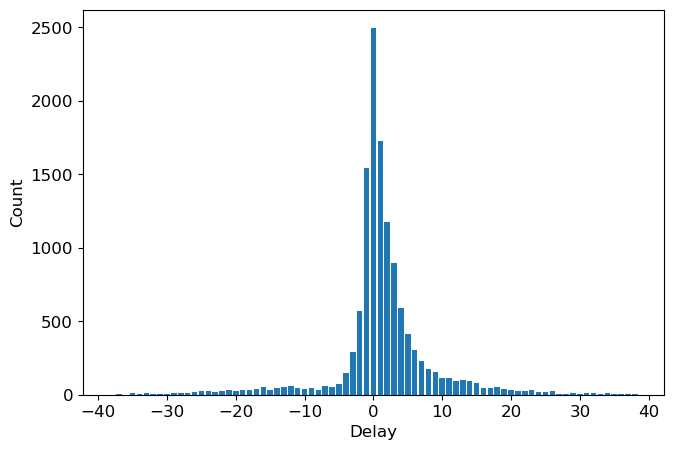

In [56]:
import matplotlib.pyplot as plt
# Create a bar plot of the delays
unique_delays, counts = np.unique(all_delays, return_counts=True)
scale = 0.5
plt.figure(figsize=(15 * scale, 10 * scale))
plt.bar(unique_delays, counts)  # Normalize to get density
plt.xlabel('Delay', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()